# 00 — Quick Pretrained YOLO26 Baseline

**Goal:** Confirm that YOLO26 loads and runs correctly in Colab *before* any dataset work.

This notebook:
1. Installs dependencies
2. Checks GPU availability
3. Loads a pretrained YOLO26 detector (COCO weights)
4. Downloads a few sample driving images
5. Runs inference and visualises predictions
6. Saves predicted images and prints detected classes with confidence scores

> ⚠️ This is **not** a BDD-trained model. It uses COCO-pretrained weights as a sanity check.

## 1 — Install Dependencies

In [1]:
# Install ultralytics (includes YOLO26 support)
!pip install -q ultralytics>=8.4.0 opencv-python matplotlib Pillow

## 2 — GPU Check

In [2]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"✅ GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("⚠️ No GPU detected! Go to Runtime → Change runtime type → GPU")

✅ GPU: Tesla T4 (14.6 GB)


## 3 — Mount Google Drive (optional)

Mount Drive if you want to save outputs persistently.

In [3]:
# Uncomment to mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

## 4 — Path Configuration

In [4]:
import os

# Output directory for saved predictions
OUTPUT_DIR = "outputs/00_baseline"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Optional: save to Google Drive instead
# OUTPUT_DIR = "/content/drive/MyDrive/EcoCAR/outputs/00_baseline"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: outputs/00_baseline


## 5 — Load Pretrained YOLO26

In [5]:
from ultralytics import YOLO

# Load YOLO26 nano — pretrained on COCO (80 classes)
# This will auto-download the weights on first run (~6 MB for nano)
model = YOLO("yolo26n.pt")

print(f"\n✅ Model loaded successfully!")
print(f"   Model type: {model.task}")
print(f"   Number of classes: {len(model.names)}")
print(f"   Class names: {list(model.names.values())[:10]}...")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

✅ Model loaded successfully!
   Model type: detect
   Number of classes: 80
   Class names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']...


## 6 — Download Sample Driving Images

We'll download a few public driving scene images for quick testing.

In [6]:
import urllib.request

SAMPLE_DIR = "sample_images"
os.makedirs(SAMPLE_DIR, exist_ok=True)

# Sample images from Ultralytics assets (public, no auth required)
sample_urls = {
    "bus.jpg": "https://ultralytics.com/images/bus.jpg",
    "zidane.jpg": "https://ultralytics.com/images/zidane.jpg",
}

for name, url in sample_urls.items():
    path = os.path.join(SAMPLE_DIR, name)
    if not os.path.exists(path):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"Already exists: {name}")

sample_images = [os.path.join(SAMPLE_DIR, f) for f in os.listdir(SAMPLE_DIR)
                 if f.endswith(('.jpg', '.png', '.jpeg'))]
print(f"\n✅ {len(sample_images)} sample images ready")


✅ 2 sample images ready


## 7 — Run Inference

In [7]:
# Run inference on all sample images
results = model(sample_images, verbose=False)

print(f"✅ Inference complete on {len(results)} images")

✅ Inference complete on 2 images


## 8 — Visualise Predictions

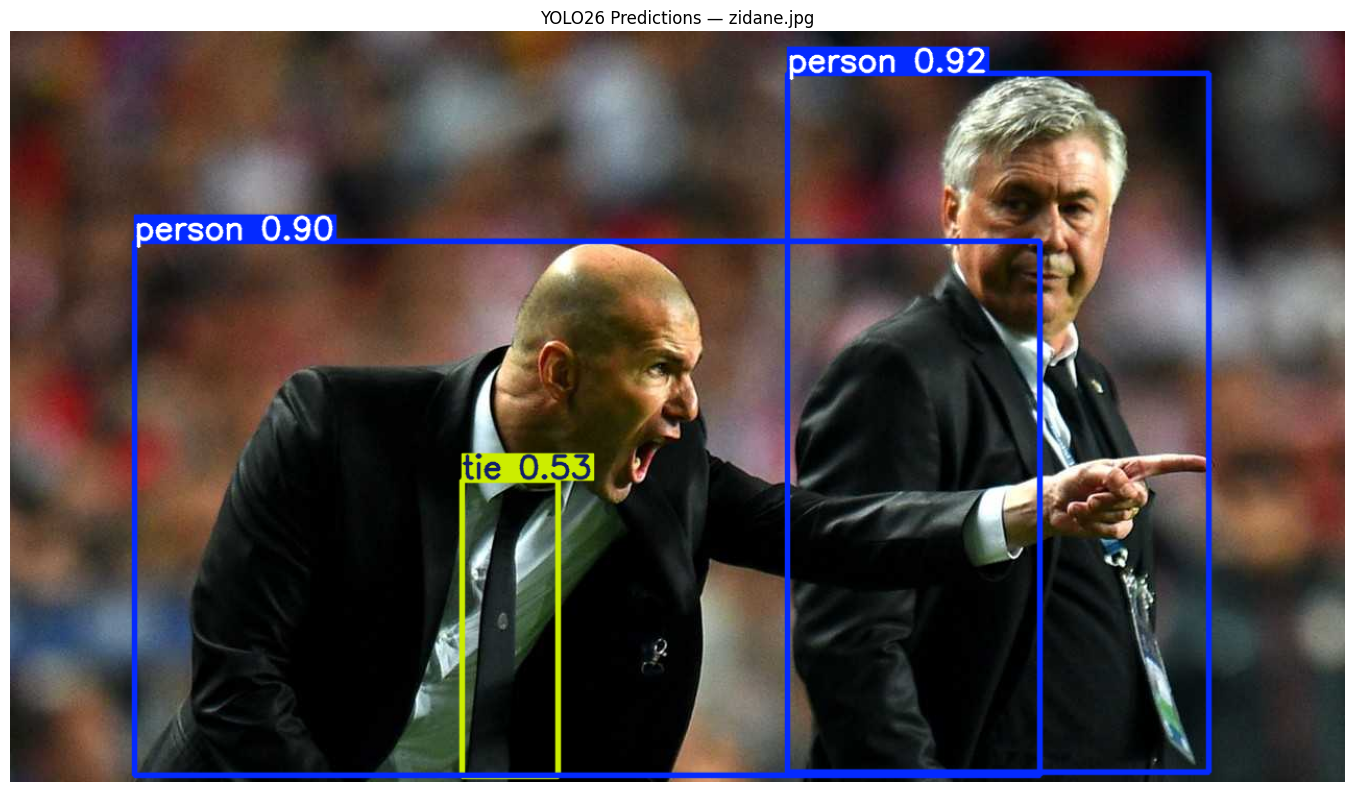

💾 Saved: outputs/00_baseline/pred_zidane.jpg


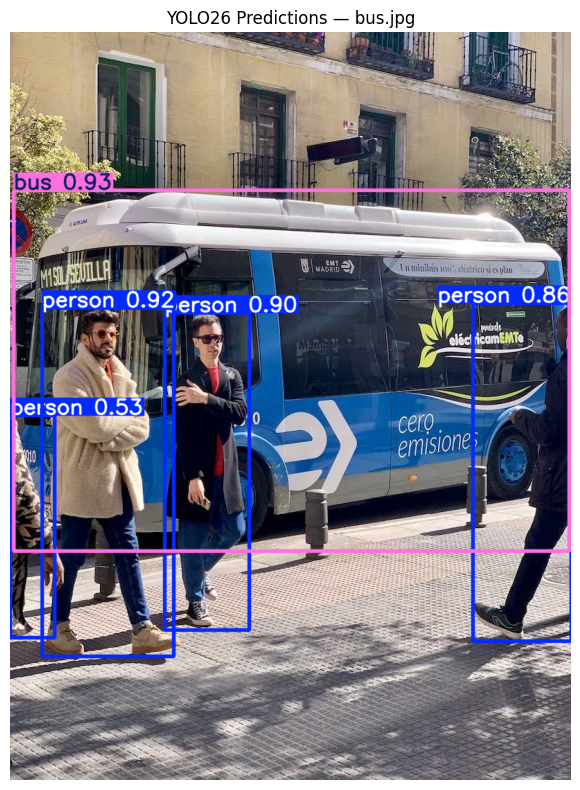

💾 Saved: outputs/00_baseline/pred_bus.jpg


In [8]:
import matplotlib.pyplot as plt
import cv2

for i, result in enumerate(results):
    # Get annotated image
    annotated = result.plot()  # BGR numpy array

    # Display
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"YOLO26 Predictions — {os.path.basename(sample_images[i])}")
    plt.tight_layout()
    plt.show()

    # Save
    save_path = os.path.join(OUTPUT_DIR, f"pred_{os.path.basename(sample_images[i])}")
    cv2.imwrite(save_path, annotated)
    print(f"💾 Saved: {save_path}")

## 9 — Print Detected Classes and Confidence Scores

In [9]:
for i, result in enumerate(results):
    print(f"\n{'='*60}")
    print(f"Image: {os.path.basename(sample_images[i])}")
    print(f"{'='*60}")

    boxes = result.boxes
    if len(boxes) == 0:
        print("  No detections.")
        continue

    print(f"  {'Class':<20} {'Confidence':>10} {'Box (x1,y1,x2,y2)'}")
    print(f"  {'-'*55}")

    for box in boxes:
        cls_id = int(box.cls.item())
        cls_name = model.names[cls_id]
        conf = box.conf.item()
        coords = box.xyxy[0].cpu().numpy().astype(int)
        print(f"  {cls_name:<20} {conf:>10.3f} ({coords[0]}, {coords[1]}, {coords[2]}, {coords[3]})")

    print(f"  Total detections: {len(boxes)}")


Image: zidane.jpg
  Class                Confidence Box (x1,y1,x2,y2)
  -------------------------------------------------------
  person                    0.918 (745, 40, 1149, 710)
  person                    0.903 (119, 201, 987, 713)
  tie                       0.530 (433, 430, 525, 714)
  Total detections: 3

Image: bus.jpg
  Class                Confidence Box (x1,y1,x2,y2)
  -------------------------------------------------------
  bus                       0.925 (5, 228, 807, 749)
  person                    0.915 (46, 398, 236, 901)
  person                    0.899 (223, 405, 345, 863)
  person                    0.860 (668, 391, 810, 879)
  person                    0.525 (0, 553, 64, 874)
  Total detections: 5


## 10 — Sanity Check Summary

In [10]:
print("\n" + "="*60)
print(" YOLO26 BASELINE — STATUS CHECK")
print("="*60)
print(f" ✅ YOLO26 model loaded:     YES")
print(f" ✅ Inference works:          YES")
print(f" ✅ GPU available:            {'YES' if torch.cuda.is_available() else 'NO (using CPU)'}")
print(f" ✅ Images processed:         {len(results)}")
total_dets = sum(len(r.boxes) for r in results)
print(f" ✅ Total detections:         {total_dets}")
print(f" ✅ Outputs saved to:         {OUTPUT_DIR}")
print("="*60)
print("\n🎯 Baseline confirmed! Proceed to notebook 01 for BDD100K dataset setup.")


 YOLO26 BASELINE — STATUS CHECK
 ✅ YOLO26 model loaded:     YES
 ✅ Inference works:          YES
 ✅ GPU available:            YES
 ✅ Images processed:         2
 ✅ Total detections:         8
 ✅ Outputs saved to:         outputs/00_baseline

🎯 Baseline confirmed! Proceed to notebook 01 for BDD100K dataset setup.


---

### Next Steps

This notebook confirmed that YOLO26 loads and runs correctly. The model above uses **COCO pretrained weights** (80 general classes).

In the next notebooks, we will:
1. **01** — Download & extract the official BDD100K dataset (70K train / 10K val)
2. **02** — Convert BDD100K annotations to YOLO format & create a cached tar artifact
3. **03** — Fine-tune YOLO26 on BDD100K for driving scene detection
4. **04** — Run inference with the fine-tuned model
5. **05** — Extract backbone/neck features for multi-task learning
6. **06** — Inspect the model architecture in detail
7. **07** — Prepare lane segmentation masks
8. **08** — Joint detection + lane training
9. **09** — Joint inference & evaluation